<a href="https://colab.research.google.com/github/J-Aamir/FineTuned-Finance-Models-Evaluation-using-Judge/blob/main/Evaluation%20and%20Judgement%20with%20baseline%20models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.7 MB/s eta 0:00:00
✅ Done — restart runtime if first run, then run from Cell 2
Mounted at /content/drive

✅ Outputs → /content/drive/MyDrive/assignment3/Judgement_responses_NEW
✅ Groq connected | Judge: llama-3.3-70b-versatile
   Baselines : ['qwen_32b', 'gpt_oss_20b']
✅ Fine-tuned answers:
   Mistral-7B — Standard SFT               : 20 answers
   Qwen2.5-7B — Improved SFT               : 20 answers
   Nemo-12B — Curriculum+DPO               : 20 answers

📝 Generating Qwen-32B (Baseline)...
   [ 1/20] What is the difference between a stock and a bond?...
   [ 2/20] How does compound interest work and why is it important?...
   [ 3/20] What is a P/E ratio and how is it used in stock valuation?...
   [ 4/20] Explain the concept of diversification in investing....
   [ 5/20] What is inflation and how does it affect purchasing power?...
   [ 6/20] What is the difference between a bull market and a bear ma...
   [ 7/20] How do ce

/tmp/ipykernel_6034/2802803170.py:482: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6034/2802803170.py:483: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{GRAPHS}/1_main_comparison.png", dpi=160, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


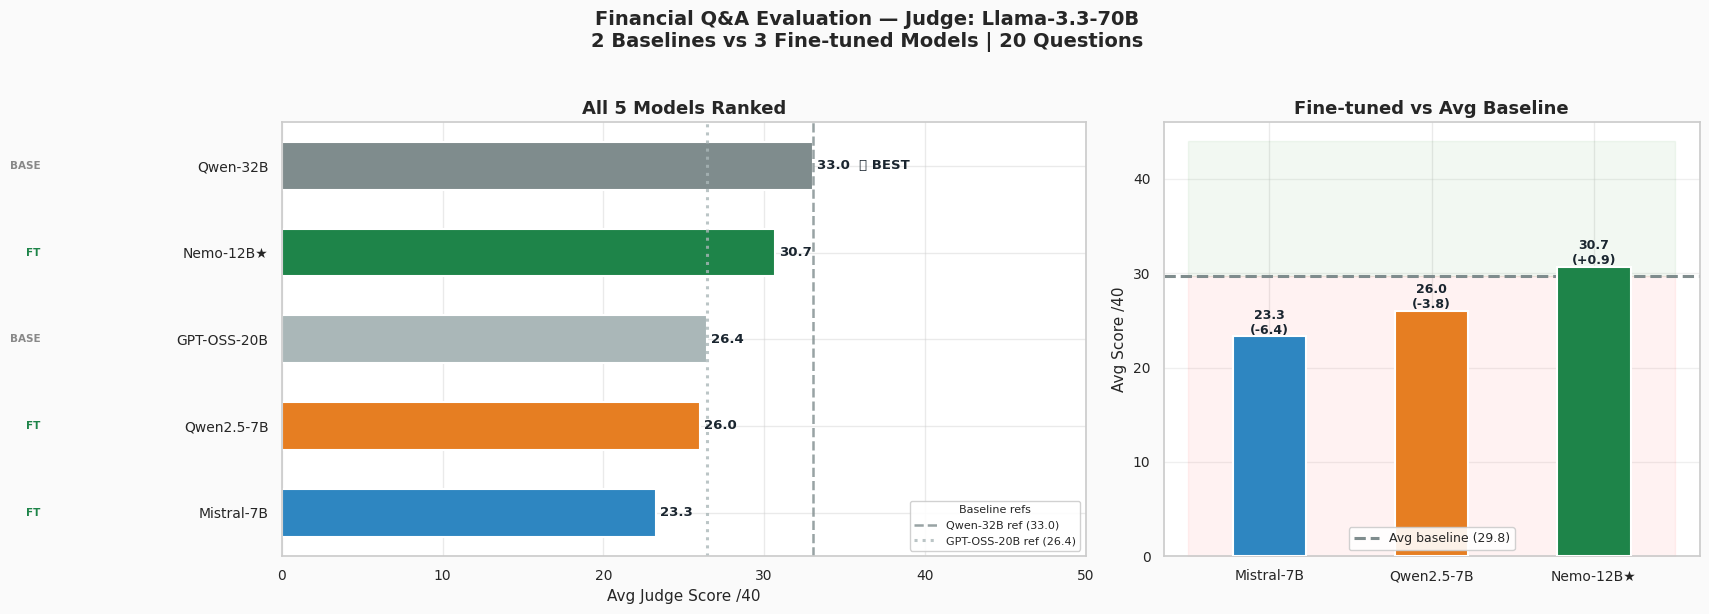

✅ Fig 1 saved


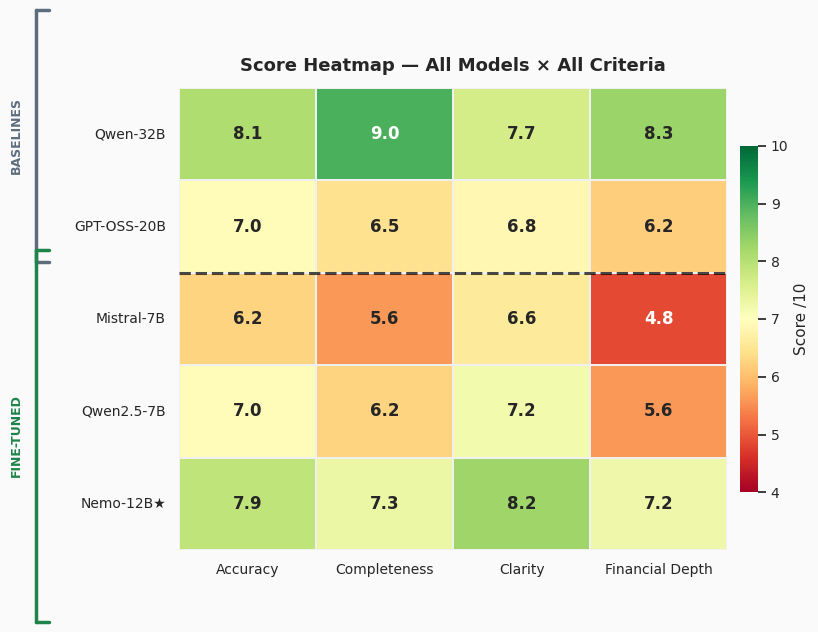

✅ Fig 2 saved


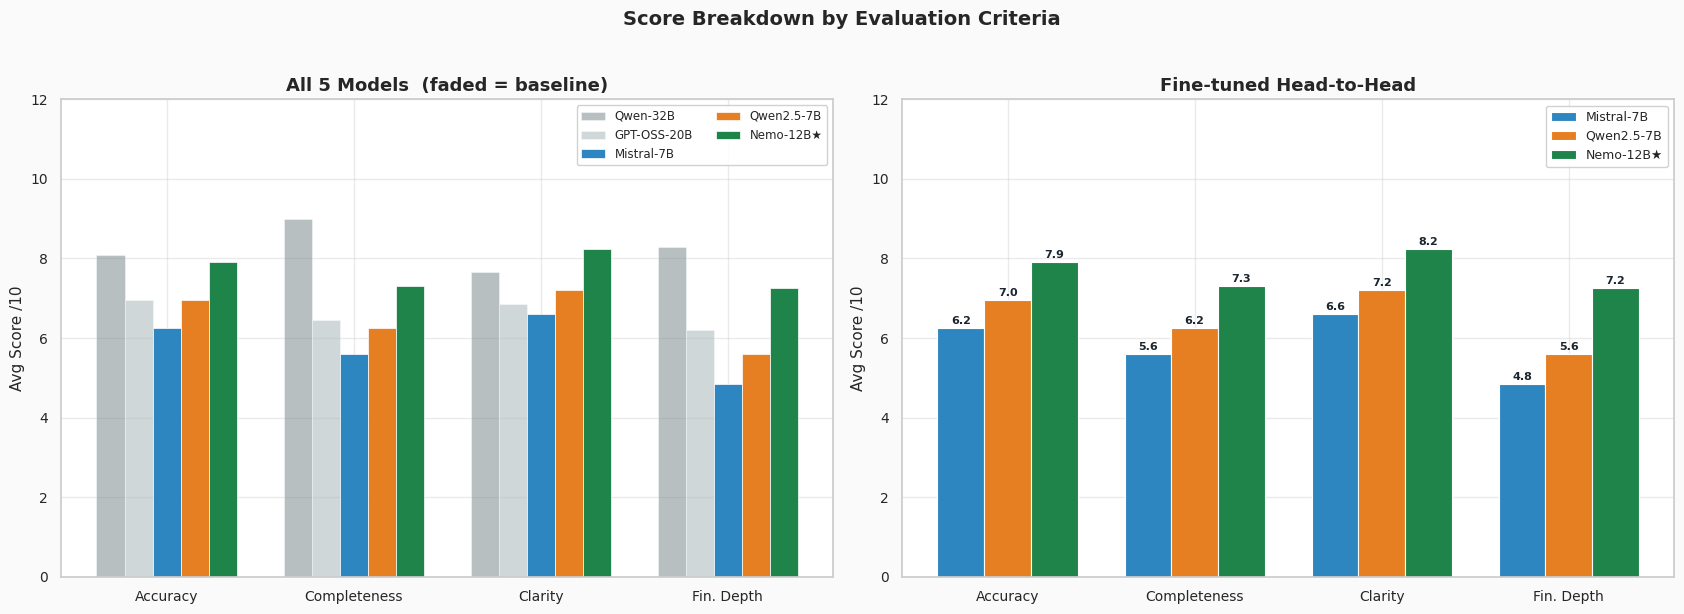

✅ Fig 3 saved


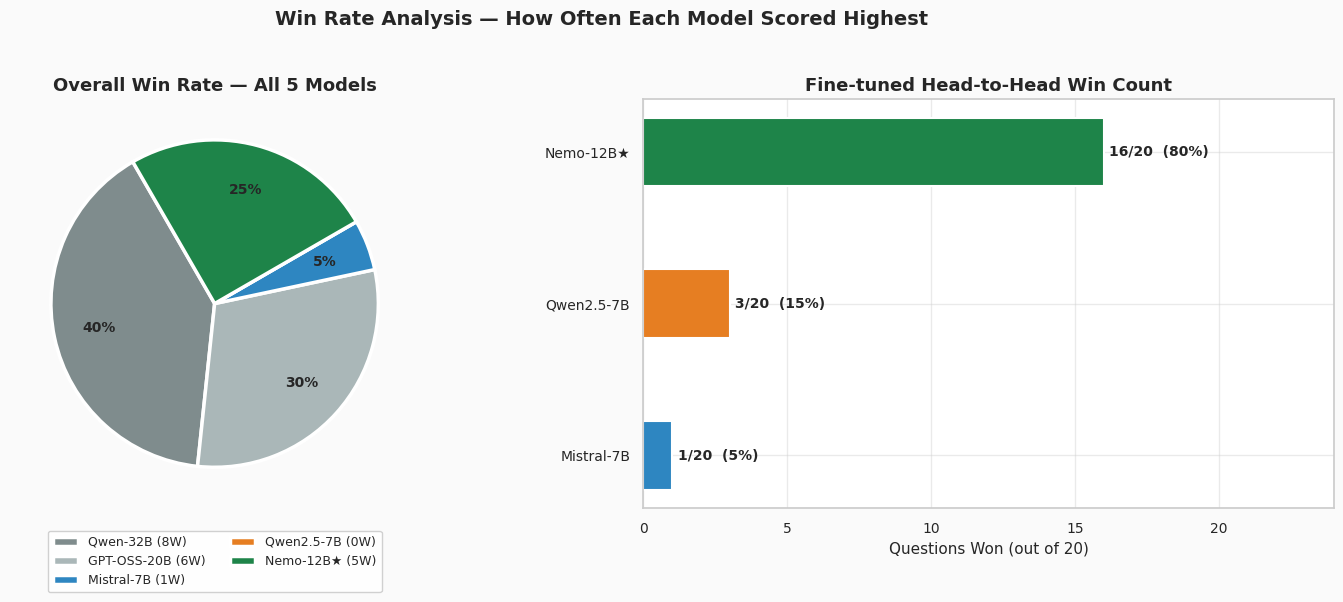

✅ Fig 4 saved


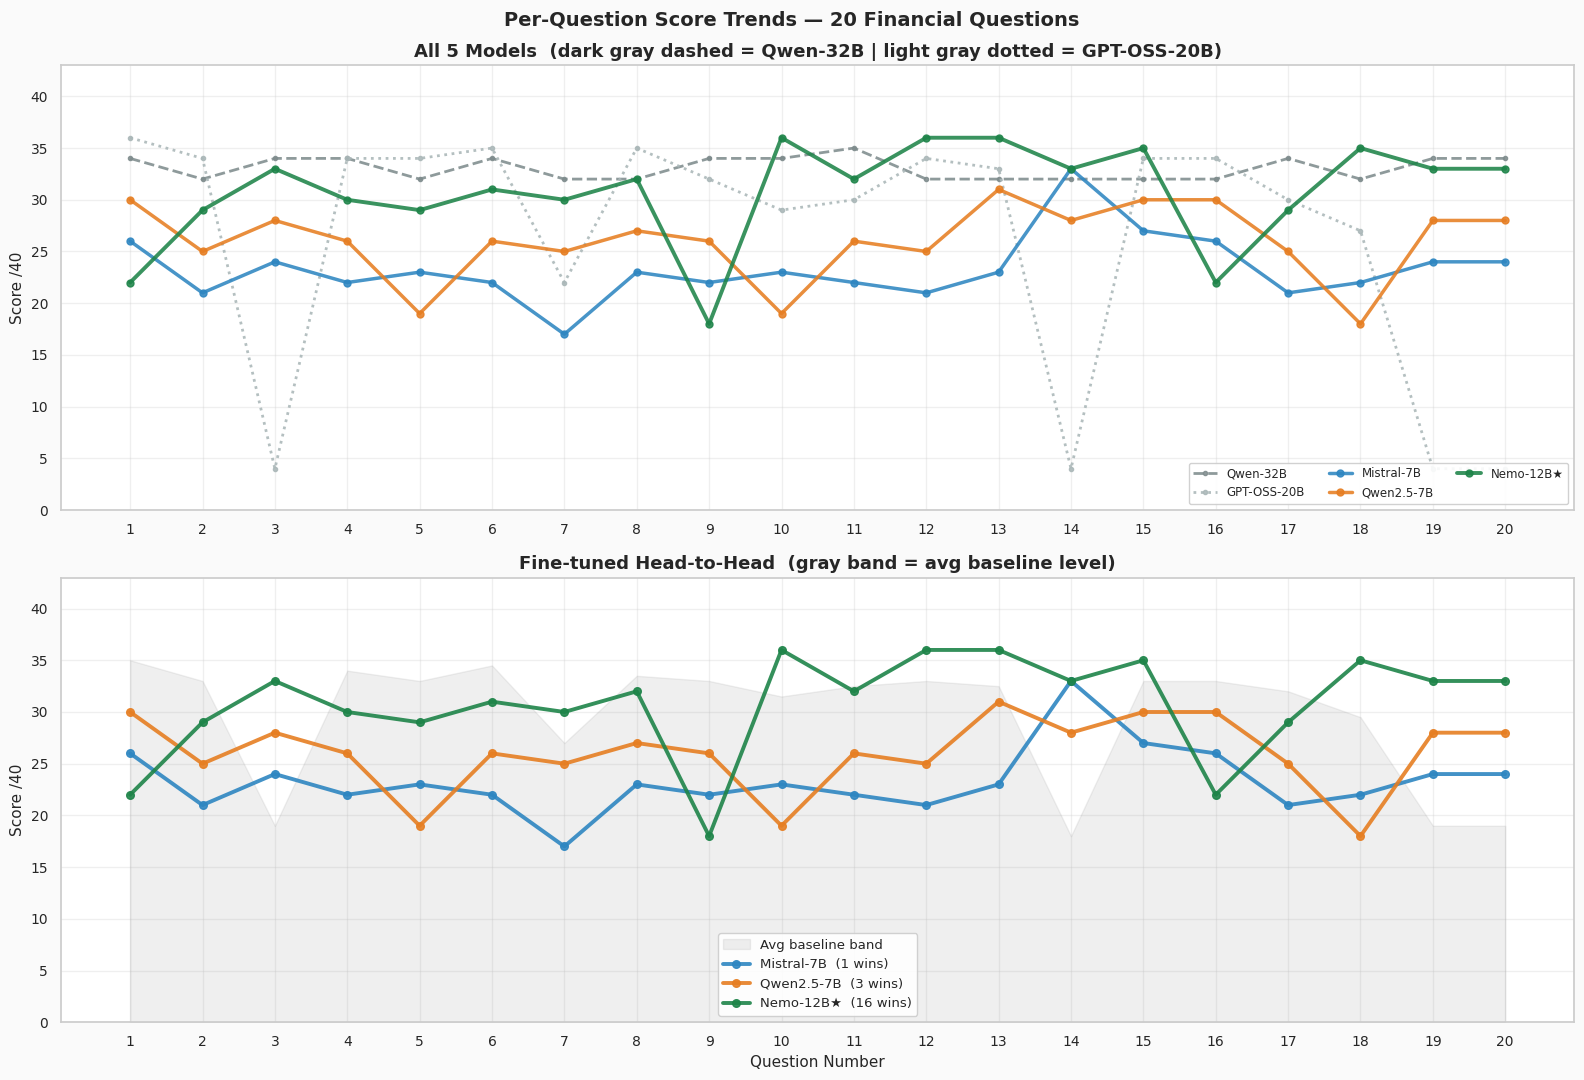

✅ Fig 5 saved


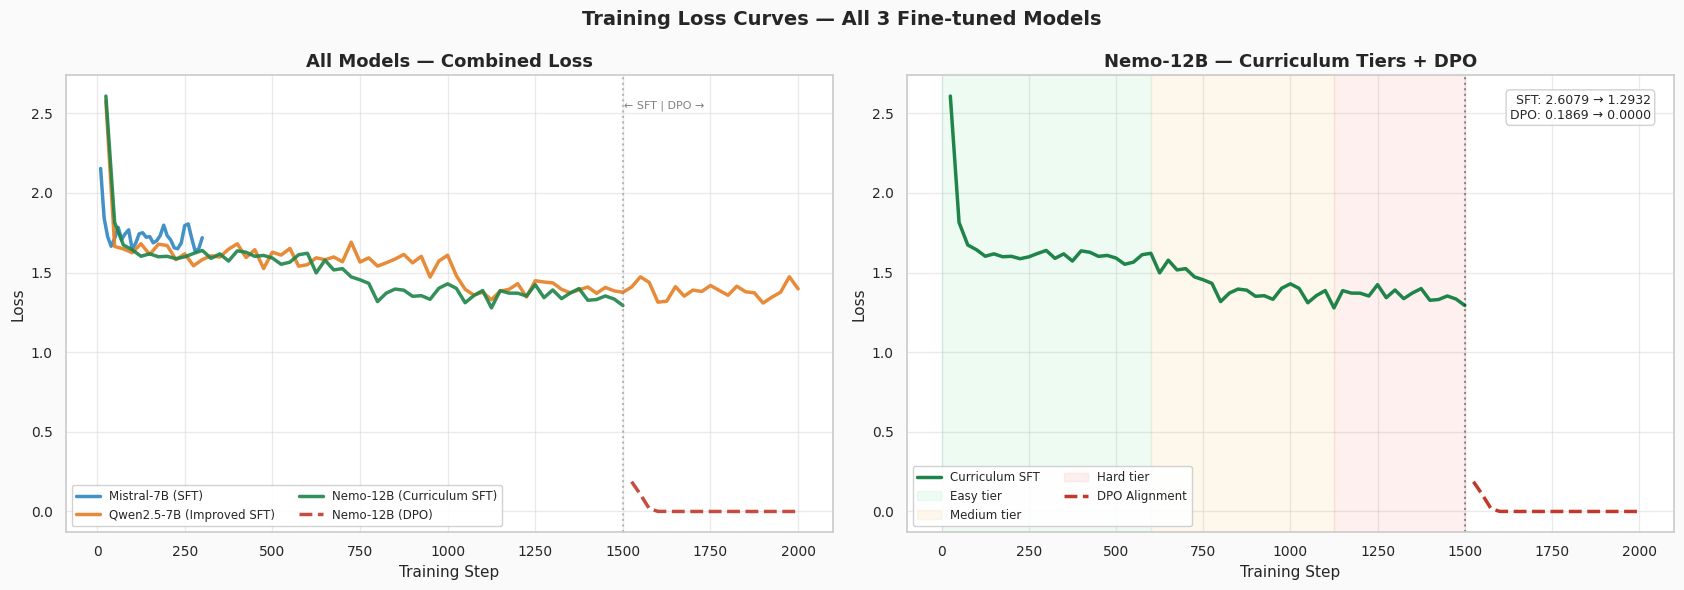

✅ Fig 6 saved

  REPORT SUMMARY
  Judge          : llama-3.3-70b-versatile
  Scored         : 20/20
  Avg baseline   : 29.75/40
  Best FT model  : Nemo-12B — Curriculum+DPO
  Best FT score  : 30.70/40  (+0.95 vs baseline)

  Files in /content/drive/MyDrive/assignment3/Judgement_responses_NEW:
    judge_results.json
    summary_table.csv
    per_question.csv
    final_analysis.json
    graphs/1_main_comparison.png
    graphs/2_heatmap.png
    graphs/3_criteria.png
    graphs/4_win_rate.png
    graphs/5_per_question.png
    graphs/6_training_loss.png


In [1]:
# ============================================================
# NOTEBOOK 4 — FINAL CLEAN v3
# ============================================================
# NO GPU NEEDED → Runtime → Change runtime type → CPU
#
# BASELINES (2, no fine-tuning):
#   • Qwen-32B       → qwen/qwen3-32b
#   • GPT-OSS-20B    → openai/gpt-oss-20b
#
# FINE-TUNED (3):
#   • Mistral-7B     → Standard SFT
#   • Qwen2.5-7B     → Improved SFT
#   • Nemo-12B       → Curriculum SFT + DPO
#
# JUDGE: llama-3.3-70b-versatile
#
# ALL outputs → assignment3/Judgement_responses/
# ============================================================

# ── CELL 1: Install ───────────────────────────────────────────
get_ipython().system('pip install -q groq pandas matplotlib seaborn')
print("✅ Done — restart runtime if first run, then run from Cell 2")

# ── CELL 2: Imports & style ───────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import json, os, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from groq import Groq

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FFFFFF',
    'axes.edgecolor'    : '#CCCCCC',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.9,
    'grid.alpha'        : 0.4,
})

BASE    = "/content/drive/MyDrive/assignment3"
OUT_DIR = f"{BASE}/Judgement_responses_NEW"
GRAPHS  = f"{OUT_DIR}/graphs"
for d in [OUT_DIR, GRAPHS]:
    os.makedirs(d, exist_ok=True)

print(f"\n✅ Outputs → {OUT_DIR}")

# ── CELL 3: Config — single source of truth ───────────────────
GROQ_API_KEY = "gsk"   # ← paste here

BASELINE_IDS = {
    "qwen_32b"   : "qwen/qwen3-32b",
    "gpt_oss_20b": "openai/gpt-oss-20b",
}
JUDGE_ID = "llama-3.3-70b-versatile"

BASELINE_KEYS = ["qwen_32b", "gpt_oss_20b"]
FT_KEYS       = ["mistral_7b", "qwen_7b", "nemo_12b"]
ALL_KEYS      = BASELINE_KEYS + FT_KEYS

NAMES = {
    "qwen_32b"   : "Qwen-32B (Baseline)",
    "gpt_oss_20b": "GPT-OSS-20B (Baseline)",
    "mistral_7b" : "Mistral-7B — Standard SFT",
    "qwen_7b"    : "Qwen2.5-7B — Improved SFT",
    "nemo_12b"   : "Nemo-12B — Curriculum+DPO",
}
SHORT = {
    "qwen_32b"   : "Qwen-32B",
    "gpt_oss_20b": "GPT-OSS-20B",
    "mistral_7b" : "Mistral-7B",
    "qwen_7b"    : "Qwen2.5-7B",
    "nemo_12b"   : "Nemo-12B★",
}
COLORS = {
    "qwen_32b"   : "#7F8C8D",   # dark gray
    "gpt_oss_20b": "#AAB7B8",   # light gray
    "mistral_7b" : "#2E86C1",   # blue
    "qwen_7b"    : "#E67E22",   # orange
    "nemo_12b"   : "#1E8449",   # green
}
# Line styles for per-question chart — baselines distinguished
LINE_STYLES = {
    "qwen_32b"   : (2.0, '--'),    # dashed
    "gpt_oss_20b": (2.0, ':'),     # dotted  ← different from qwen
    "mistral_7b" : (2.5, '-'),
    "qwen_7b"    : (2.5, '-'),
    "nemo_12b"   : (2.8, '-'),
}

client = Groq(api_key=GROQ_API_KEY)
try:
    client.chat.completions.create(
        model=JUDGE_ID,
        messages=[{"role":"user","content":"ping"}],
        max_tokens=3
    )
    print(f"✅ Groq connected | Judge: {JUDGE_ID}")
    print(f"   Baselines : {list(BASELINE_IDS.keys())}")
except Exception as e:
    print(f"❌ Connection error: {e}")

# ── CELL 4: Load fine-tuned answers & training stats ──────────
def jload(path):
    return json.load(open(path)) if os.path.exists(path) else {}

with open(f"{BASE}/mistral7b_financial/test_questions.json") as f:
    QUESTIONS = json.load(f)

FT_ANSWERS = {
    "mistral_7b": jload(f"{BASE}/mistral7b_financial/mistral_answers.json"),
    "qwen_7b"   : jload(f"{BASE}/qwen25_7b_financial/qwen_answers.json"),
    "nemo_12b"  : jload(f"{BASE}/mistral_nemo_financial/nemo_answers.json"),
}
TRAIN_STATS = {
    "mistral_7b": jload(f"{BASE}/mistral7b_financial/training_stats.json"),
    "qwen_7b"   : jload(f"{BASE}/qwen25_7b_financial/training_stats.json"),
    "nemo_12b"  : jload(f"{BASE}/mistral_nemo_financial/training_stats.json"),
}

print("✅ Fine-tuned answers:")
for k, v in FT_ANSWERS.items():
    print(f"   {NAMES[k]:40s}: {len(v)} answers"
          if v else f"   {NAMES[k]:40s}: ⚠️  NOT FOUND")

# ── CELL 5: Generate baseline answers ────────────────────────
SYS_PROMPT = (
    "You are a senior financial analyst with CFA certification. "
    "Provide accurate, well-structured, and insightful financial answers."
)

def call_model(question, model_id, retries=3):
    for attempt in range(retries):
        try:
            r = client.chat.completions.create(
                model    = model_id,
                messages = [
                    {"role": "system", "content": SYS_PROMPT},
                    {"role": "user",   "content": question},
                ],
                max_tokens  = 500,
                temperature = 0.7,
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            print(f"   Attempt {attempt+1}/3 failed: {e}")
            time.sleep(4 * (attempt+1))
    return "Error: could not generate answer"

BASELINE_ANSWERS = {}
for nick, model_id in BASELINE_IDS.items():
    path = f"{OUT_DIR}/baseline_{nick}.json"
    if os.path.exists(path):
        with open(path) as f:
            BASELINE_ANSWERS[nick] = json.load(f)
        print(f"✅ Loaded {nick}: {len(BASELINE_ANSWERS[nick])} answers")
        continue
    print(f"\n📝 Generating {NAMES[nick]}...")
    answers = {}
    for i, q in enumerate(QUESTIONS):
        print(f"   [{i+1:2d}/20] {q[:58]}...")
        answers[q] = call_model(q, model_id)
        time.sleep(1.5)
    BASELINE_ANSWERS[nick] = answers
    with open(path, "w") as f:
        json.dump(answers, f, indent=2)
    print(f"✅ Saved baseline_{nick}.json")

print("\n✅ Both baselines ready")

# ── CELL 6: Judge prompt (5 models) ──────────────────────────
JUDGE_PROMPT = """\
You are an expert financial evaluation judge.

Evaluate the five answers below for the given financial question.
Differentiate scores clearly — do NOT give all models the same score.

Scoring criteria (each 1–10, integers only):
  accuracy        — Financial facts are correct and precise
  completeness    — All aspects of the question are addressed
  clarity         — Well-structured, logical, easy to follow
  financial_depth — Demonstrates real financial expertise and insight

total = accuracy + completeness + clarity + financial_depth  (max 40)

Return ONLY valid JSON — no explanation, no markdown fences, no extra text.
Use this exact structure:

{{
  "qwen_32b":    {{"accuracy":0,"completeness":0,"clarity":0,"financial_depth":0,"total":0,"verdict":"one sentence"}},
  "gpt_oss_20b": {{"accuracy":0,"completeness":0,"clarity":0,"financial_depth":0,"total":0,"verdict":"one sentence"}},
  "mistral_7b":  {{"accuracy":0,"completeness":0,"clarity":0,"financial_depth":0,"total":0,"verdict":"one sentence"}},
  "qwen_7b":     {{"accuracy":0,"completeness":0,"clarity":0,"financial_depth":0,"total":0,"verdict":"one sentence"}},
  "nemo_12b":    {{"accuracy":0,"completeness":0,"clarity":0,"financial_depth":0,"total":0,"verdict":"one sentence"}}
}}

Replace every 0 with an integer score (1–10) and fill each verdict with one sentence.

===== QUESTION =====
{question}

===== Baseline 1 — Qwen-32B (not fine-tuned on finance) =====
{qwen_32b}

===== Baseline 2 — GPT-OSS-20B (not fine-tuned on finance) =====
{gpt_oss_20b}

===== Fine-tuned 1 — Mistral-7B Standard SFT =====
{mistral_7b}

===== Fine-tuned 2 — Qwen2.5-7B Improved SFT =====
{qwen_7b}

===== Fine-tuned 3 — Nemo-12B Curriculum SFT + DPO =====
{nemo_12b}
"""

# ── CELL 7: Robust JSON extraction ───────────────────────────
def extract_json(raw: str) -> dict:
    """4-strategy JSON extraction — handles all common LLM formatting issues."""
    raw = raw.strip()

    # 1. Strip markdown fences
    for fence in ["```json", "```"]:
        if fence in raw:
            for part in raw.split(fence):
                part = part.strip().rstrip("`").strip()
                if part.startswith("{"):
                    raw = part
                    break

    # 2. Extract first { ... last }
    start = raw.find("{")
    end   = raw.rfind("}") + 1
    if start != -1 and end > start:
        raw = raw[start:end]

    # 3. Fix trailing commas before } or ]
    raw = re.sub(r',\s*([}\]])', r'\1', raw)

    # 4. Fix unquoted property names (common with some models)
    raw = re.sub(r'(?<=[{,])\s*([a-zA-Z_][a-zA-Z0-9_]*)\s*:', r'"\1":', raw)

    return json.loads(raw)

def validate_and_fix(scores: dict) -> dict:
    """Ensure all keys present, recompute totals, clamp scores 1-10."""
    required = {"accuracy","completeness","clarity","financial_depth","total","verdict"}
    for k in ALL_KEYS:
        if k not in scores:
            raise ValueError(f"Missing model key in JSON: {k}")
        missing = required - set(scores[k].keys())
        if missing:
            raise ValueError(f"Missing fields for {k}: {missing}")
        # Clamp
        for c in ["accuracy","completeness","clarity","financial_depth"]:
            scores[k][c] = max(1, min(10, int(scores[k][c])))
        # Recompute total (catches LLM arithmetic errors)
        scores[k]["total"] = (scores[k]["accuracy"] + scores[k]["completeness"]
                             + scores[k]["clarity"] + scores[k]["financial_depth"])
    return scores

# ── CELL 8: Run judge — all 20 questions, fresh run ───────────
RESULTS_PATH = f"{OUT_DIR}/judge_results.json"

# Always fresh — comment out next 2 lines to resume instead
all_results = []
done        = set()

# ── Uncomment these 3 lines to RESUME a partial run ──────────
# if os.path.exists(RESULTS_PATH):
#     with open(RESULTS_PATH) as f: all_results = json.load(f)
#     done = {r["question"] for r in all_results}; print(f"Resuming {len(all_results)}/20")

remaining = [q for q in QUESTIONS if q not in done]
print(f"⚖️  Judge   : {JUDGE_ID}")
print(f"   Models  : {ALL_KEYS}")
print(f"   Scoring : {len(remaining)} questions\n")

for question in remaining:
    idx = QUESTIONS.index(question) + 1
    print(f"[{idx:2d}/20] {question[:62]}...")

    prompt = JUDGE_PROMPT.format(
        question    = question,
        qwen_32b    = BASELINE_ANSWERS["qwen_32b"].get(question,    "No answer."),
        gpt_oss_20b = BASELINE_ANSWERS["gpt_oss_20b"].get(question, "No answer."),
        mistral_7b  = FT_ANSWERS["mistral_7b"].get(question, "No answer."),
        qwen_7b     = FT_ANSWERS["qwen_7b"].get(question,    "No answer."),
        nemo_12b    = FT_ANSWERS["nemo_12b"].get(question,   "No answer."),
    )

    success = False
    for attempt in range(4):
        try:
            r = client.chat.completions.create(
                model    = JUDGE_ID,
                messages = [{"role": "user", "content": prompt}],
                max_tokens  = 1200,
                temperature = 0.05,
            )
            raw    = r.choices[0].message.content
            scores = extract_json(raw)
            scores = validate_and_fix(scores)

            all_results.append({"question": question, "scores": scores})

            row = " | ".join([
                f"{SHORT[k]}:{scores[k]['total']}"
                for k in ALL_KEYS
            ])
            print(f"       {row}")

            with open(RESULTS_PATH, "w") as f:
                json.dump(all_results, f, indent=2)

            success = True
            break

        except (json.JSONDecodeError, ValueError, KeyError) as e:
            print(f"   ⚠️  Parse error attempt {attempt+1}/4: {e}")
            time.sleep(3)
        except Exception as e:
            print(f"   ⚠️  API error attempt {attempt+1}/4: {e}")
            time.sleep(6*(attempt+1))

    if not success:
        print(f"   ❌ Skipping Q{idx} after 4 failed attempts")

    time.sleep(2.5)

print(f"\n✅ Done — {len(all_results)}/20 scored")
print(f"   Saved: {RESULTS_PATH}")

# ── CELL 9: Aggregate ────────────────────────────────────────
CRITERIA = ["accuracy","completeness","clarity","financial_depth"]

agg = {k: {c: [] for c in CRITERIA+["total"]} for k in ALL_KEYS}
for r in all_results:
    for k in ALL_KEYS:
        entry = r["scores"].get(k, {})
        for c in CRITERIA:
            agg[k][c].append(entry.get(c, 0))
        agg[k]["total"].append(entry.get("total", 0))

def avg(lst):
    return round(float(np.mean(lst)), 2) if lst else 0.0

rows = []
for k in ALL_KEYS:
    rows.append({
        "Model"          : NAMES[k],
        "Type"           : "Baseline" if k in BASELINE_KEYS else "Fine-tuned",
        "Accuracy"       : avg(agg[k]["accuracy"]),
        "Completeness"   : avg(agg[k]["completeness"]),
        "Clarity"        : avg(agg[k]["clarity"]),
        "Financial Depth": avg(agg[k]["financial_depth"]),
        "Total /40"      : avg(agg[k]["total"]),
    })

df = (pd.DataFrame(rows)
        .sort_values("Total /40", ascending=False)
        .reset_index(drop=True))
df.index += 1

print("\n" + "="*85)
print(f"  RESULTS  |  Judge: {JUDGE_ID}  |  {len(all_results)}/20 questions")
print("="*85)
print(df.to_string())
print("="*85)
df.to_csv(f"{OUT_DIR}/summary_table.csv", index=True)

wins_all = {k: 0 for k in ALL_KEYS}
wins_ft  = {k: 0 for k in FT_KEYS}
for r in all_results:
    t  = {k: r["scores"].get(k,{}).get("total",0) for k in ALL_KEYS}
    wins_all[max(t, key=t.get)] += 1
    tf = {k: r["scores"].get(k,{}).get("total",0) for k in FT_KEYS}
    wins_ft[max(tf, key=tf.get)] += 1

avg_baseline = avg([avg(agg[k]["total"]) for k in BASELINE_KEYS])

print(f"\n  Avg baseline : {avg_baseline:.2f}/40")
print(f"  Best FT      : {max(avg(agg[k]['total']) for k in FT_KEYS):.2f}/40")
print("\n  FT win rates:")
for k in FT_KEYS:
    pct = round(wins_ft[k]/len(all_results)*100,0) if all_results else 0
    print(f"    {NAMES[k]:42s}: {wins_ft[k]}/20  ({int(pct)}%)")

# ── CELL 10: VISUALIZATIONS ──────────────────────────────────

# ════════════════════════════════════════════════════════════
# FIG 1: Main bar (all 5) + FT vs baseline gap
# ════════════════════════════════════════════════════════════
fig, (ax_main, ax_gap) = plt.subplots(
    1, 2, figsize=(17, 6),
    gridspec_kw={'width_ratios': [3, 2]}
)
fig.suptitle(
    f"Financial Q&A Evaluation — Judge: Llama-3.3-70B\n"
    f"2 Baselines vs 3 Fine-tuned Models | 20 Questions",
    fontsize=14, fontweight='bold', y=1.02
)

# Sorted horizontal bar
sk     = sorted(ALL_KEYS, key=lambda k: avg(agg[k]["total"]))
s_vals = [avg(agg[k]["total"]) for k in sk]
s_cols = [COLORS[k] for k in sk]
s_lbls = [SHORT[k] for k in sk]

bars = ax_main.barh(s_lbls, s_vals, color=s_cols,
                    edgecolor='white', linewidth=1.5, height=0.55)

for i, (bar, val, key) in enumerate(zip(bars, s_vals, sk)):
    tag = "  ⭐ BEST" if i == len(sk)-1 else ""
    ax_main.text(bar.get_width()+0.25,
                 bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}{tag}",
                 va='center', fontsize=9.5, fontweight='bold', color='#1a252f')

# Reference lines — different styles for each baseline
bl_styles = [('--', 1.8), (':', 2.2)]
for (k, (ls, lw)) in zip(BASELINE_KEYS, bl_styles):
    ax_main.axvline(x=avg(agg[k]["total"]),
                    color=COLORS[k], linestyle=ls, linewidth=lw,
                    alpha=0.8, label=f"{SHORT[k]} ref ({avg(agg[k]['total']):.1f})")

# Type tags on left
for i, k in enumerate(sk):
    tag  = "BASE" if k in BASELINE_KEYS else "FT"
    tcol = "#888" if tag=="BASE" else "#1E8449"
    ax_main.text(-0.3, i, tag, va='center', ha='right',
                 fontsize=7.5, color=tcol, fontweight='bold',
                 transform=ax_main.get_yaxis_transform())

ax_main.set_xlim(0, 50)
ax_main.set_xlabel("Avg Judge Score /40")
ax_main.set_title("All 5 Models Ranked", fontweight='bold')
ax_main.legend(title="Baseline refs", fontsize=8,
               loc='lower right', title_fontsize=8)

# FT improvement bar
ft_tots = [avg(agg[k]["total"]) for k in FT_KEYS]
ft_lbls = [SHORT[k] for k in FT_KEYS]
ft_cols = [COLORS[k] for k in FT_KEYS]
imps    = [v-avg_baseline for v in ft_tots]
imp_lbl = [f"({'+' if i>=0 else ''}{i:.1f})" for i in imps]

bars2 = ax_gap.bar(ft_lbls, ft_tots, color=ft_cols,
                   edgecolor='white', linewidth=1.5, width=0.45, zorder=3)
for bar, val, il in zip(bars2, ft_tots, imp_lbl):
    ax_gap.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3,
                f"{val:.1f}\n{il}",
                ha='center', fontsize=9, fontweight='bold', color='#1a252f')

ax_gap.axhline(y=avg_baseline, color='#7f8c8d', linewidth=2.2,
               linestyle='--', zorder=2,
               label=f"Avg baseline ({avg_baseline:.1f})")
ax_gap.fill_between([-0.5,2.5], avg_baseline, 44,
                    alpha=0.05, color='green', zorder=1)
ax_gap.fill_between([-0.5,2.5], 0, avg_baseline,
                    alpha=0.05, color='red', zorder=1)
ax_gap.set_ylim(0, 46)
ax_gap.set_ylabel("Avg Score /40")
ax_gap.set_title("Fine-tuned vs Avg Baseline", fontweight='bold')
ax_gap.legend(fontsize=9)
ax_gap.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{GRAPHS}/1_main_comparison.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Fig 1 saved")

# ════════════════════════════════════════════════════════════
# FIG 2: Heatmap — bracket labels on LEFT, no overlap with colorbar
# ════════════════════════════════════════════════════════════
crit_lbls = ["Accuracy","Completeness","Clarity","Financial Depth"]
heat_rows = [SHORT[k] for k in ALL_KEYS]
heat_data = [[avg(agg[k][c]) for c in CRITERIA] for k in ALL_KEYS]
heat_df   = pd.DataFrame(heat_data, index=heat_rows, columns=crit_lbls)

# Extra left margin for bracket labels
fig, ax = plt.subplots(figsize=(11, 6))
fig.subplots_adjust(left=0.28, right=0.88)   # room on both sides

sns.heatmap(heat_df, annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=4, vmax=10,
            linewidths=1.2, linecolor='#f0f0f0',
            ax=ax, annot_kws={"size":12, "weight":"bold"},
            cbar_kws={"shrink":0.75, "label":"Score /10",
                      "pad": 0.02})

ax.tick_params(axis='y', rotation=0)
ax.set_title("Score Heatmap — All Models × All Criteria",
             fontsize=13, fontweight='bold', pad=12)

# ── Bracket labels drawn in figure coords (left of axes) ─────
# 2 baselines = rows 0,1 → midpoint y = 1.0 in axes coords (seaborn flips y)
# 3 FT        = rows 2,3,4 → midpoint y in axes coords

n_base = len(BASELINE_KEYS)   # 2
n_ft   = len(FT_KEYS)          # 3
n_all  = len(ALL_KEYS)          # 5

# Seaborn heatmap has row 0 at top → y axis goes n→0
# axes coords: y=1 is top row, y=0 is bottom row
def row_to_axes_y(row_idx, n_rows):
    """Convert row index (0=top) to axes coordinate (0=bottom, 1=top)."""
    return 1.0 - (row_idx + 0.5) / n_rows

base_mid = np.mean([row_to_axes_y(i, n_all) for i in range(n_base)])
ft_mid   = np.mean([row_to_axes_y(i, n_all) for i in range(n_base, n_all)])

# Bracket x in figure coords (left of axes)
ax_left = ax.get_position().x0   # axes left edge in figure coords
bx      = ax_left - 0.13          # bracket x
tx      = ax_left - 0.02          # text x

for mid, label, color, rows in [
    (base_mid, "BASELINES",  "#5D6D7E", range(n_base)),
    (ft_mid,   "FINE-TUNED", "#1E8449", range(n_base, n_all)),
]:
    y0 = row_to_axes_y(list(rows)[0],  n_all) + 0.5/n_all + 0.01
    y1 = row_to_axes_y(list(rows)[-1], n_all) - 0.5/n_all - 0.01

    # Vertical bracket line
    fig.add_artist(plt.Line2D(
        [bx, bx], [y1, y0],
        transform=fig.transFigure,
        color=color, linewidth=2.5, clip_on=False
    ))
    # Top serif
    fig.add_artist(plt.Line2D(
        [bx, bx+0.012], [y0, y0],
        transform=fig.transFigure,
        color=color, linewidth=2.5, clip_on=False
    ))
    # Bottom serif
    fig.add_artist(plt.Line2D(
        [bx, bx+0.012], [y1, y1],
        transform=fig.transFigure,
        color=color, linewidth=2.5, clip_on=False
    ))
    # Label — rotated, left of bracket
    fig.text(bx-0.012, (y0+y1)/2, label,
             transform=fig.transFigure,
             ha='right', va='center', rotation=90,
             fontsize=9, fontweight='bold', color=color)

# Dashed divider between baselines and FT
ax.axhline(y=n_base, color='black', linewidth=2.2,
           linestyle='--', alpha=0.7)

plt.savefig(f"{GRAPHS}/2_heatmap.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Fig 2 saved")

# ════════════════════════════════════════════════════════════
# FIG 3: Criteria bars — all 5 + FT only
# ════════════════════════════════════════════════════════════
fig, (ax_all, ax_ft) = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Score Breakdown by Evaluation Criteria",
             fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(CRITERIA))

# All 5
w5 = 0.15
for i, k in enumerate(ALL_KEYS):
    vals   = [avg(agg[k][c]) for c in CRITERIA]
    offset = (i - 2) * w5
    alpha  = 0.55 if k in BASELINE_KEYS else 1.0
    ax_all.bar(x+offset, vals, w5, label=SHORT[k],
               color=COLORS[k], edgecolor='white',
               linewidth=0.5, alpha=alpha)

ax_all.set_title("All 5 Models  (faded = baseline)", fontweight='bold')
ax_all.set_xticks(x)
ax_all.set_xticklabels(["Accuracy","Completeness","Clarity","Fin. Depth"])
ax_all.set_ylim(0, 12); ax_all.set_ylabel("Avg Score /10")
ax_all.legend(fontsize=8.5, ncol=2)

# FT only with value labels
w3 = 0.25
for i, k in enumerate(FT_KEYS):
    vals   = [avg(agg[k][c]) for c in CRITERIA]
    offset = (i - 1) * w3
    bars   = ax_ft.bar(x+offset, vals, w3, label=SHORT[k],
                       color=COLORS[k], edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax_ft.text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.1, f"{v:.1f}",
                   ha='center', fontsize=8, fontweight='bold',
                   color='#1a252f')

ax_ft.set_title("Fine-tuned Head-to-Head", fontweight='bold')
ax_ft.set_xticks(x)
ax_ft.set_xticklabels(["Accuracy","Completeness","Clarity","Fin. Depth"])
ax_ft.set_ylim(0, 12); ax_ft.set_ylabel("Avg Score /10")
ax_ft.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{GRAPHS}/3_criteria.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Fig 3 saved")

# ════════════════════════════════════════════════════════════
# FIG 4: Win rate pie + FT horizontal bar
# ════════════════════════════════════════════════════════════
fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Win Rate Analysis — How Often Each Model Scored Highest",
             fontsize=14, fontweight='bold', y=1.02)

# Pie — all 5
pie_vals = [wins_all[k] for k in ALL_KEYS]
pie_cols = [COLORS[k]   for k in ALL_KEYS]
pie_lbls = [f"{SHORT[k]} ({wins_all[k]}W)" for k in ALL_KEYS]

def autopct_nz(pct):
    return f"{pct:.0f}%" if pct > 0 else ""

wedges, _, autotexts = ax_pie.pie(
    pie_vals, colors=pie_cols,
    autopct=autopct_nz, startangle=120, pctdistance=0.72,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax_pie.legend(wedges, pie_lbls,
              loc='lower center', bbox_to_anchor=(0.5, -0.22),
              fontsize=9, ncol=2, framealpha=0.9)
ax_pie.set_title("Overall Win Rate — All 5 Models", fontweight='bold')

# FT bar
ft_vals = [wins_ft[k] for k in FT_KEYS]
ft_lbls = [SHORT[k]   for k in FT_KEYS]
ft_cols = [COLORS[k]  for k in FT_KEYS]
bars = ax_bar.barh(ft_lbls, ft_vals, color=ft_cols,
                   edgecolor='white', linewidth=1.5, height=0.45)
for bar, val in zip(bars, ft_vals):
    pct = round(val/len(all_results)*100, 0) if all_results else 0
    ax_bar.text(bar.get_width()+0.2,
                bar.get_y()+bar.get_height()/2,
                f"{val}/20  ({int(pct)}%)",
                va='center', fontsize=10, fontweight='bold')

ax_bar.set_xlim(0, 24)
ax_bar.set_xlabel("Questions Won (out of 20)")
ax_bar.set_title("Fine-tuned Head-to-Head Win Count", fontweight='bold')

plt.tight_layout()
plt.savefig(f"{GRAPHS}/4_win_rate.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Fig 4 saved")

# ════════════════════════════════════════════════════════════
# FIG 5: Per-question trends — all 5 (top) + FT only (bottom)
# ════════════════════════════════════════════════════════════
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle("Per-Question Score Trends — 20 Financial Questions",
             fontsize=14, fontweight='bold')

q_idx = list(range(1, len(all_results)+1))

# Top: all 5 — baselines use different dash styles + smaller markers
for k in ALL_KEYS:
    s           = [r["scores"].get(k,{}).get("total",0) for r in all_results]
    lw, ls      = LINE_STYLES[k]
    ms          = 3 if k in BASELINE_KEYS else 5
    ax_top.plot(q_idx, s, color=COLORS[k], linewidth=lw,
                linestyle=ls, marker='o', markersize=ms,
                label=SHORT[k], alpha=0.88)

ax_top.set_title(
    "All 5 Models  (dark gray dashed = Qwen-32B | light gray dotted = GPT-OSS-20B)",
    fontweight='bold')
ax_top.set_ylabel("Score /40")
ax_top.set_ylim(0, 43)
ax_top.set_xticks(q_idx)
ax_top.legend(ncol=3, fontsize=8.5, loc='lower right')
ax_top.grid(True, alpha=0.3)

# Bottom: FT only + avg-baseline grey band
avg_b_per_q = [
    np.mean([r["scores"].get(k,{}).get("total",0) for k in BASELINE_KEYS])
    for r in all_results
]
ax_bot.fill_between(q_idx, 0, avg_b_per_q,
                    alpha=0.12, color='gray', label='Avg baseline band')
for k in FT_KEYS:
    s = [r["scores"].get(k,{}).get("total",0) for r in all_results]
    ax_bot.plot(q_idx, s, color=COLORS[k], linewidth=2.8,
                marker='o', markersize=5.5,
                label=f"{SHORT[k]}  ({wins_ft[k]} wins)", alpha=0.9)

ax_bot.set_title(
    "Fine-tuned Head-to-Head  (gray band = avg baseline level)",
    fontweight='bold')
ax_bot.set_xlabel("Question Number")
ax_bot.set_ylabel("Score /40")
ax_bot.set_ylim(0, 43)
ax_bot.set_xticks(q_idx)
ax_bot.legend(fontsize=9.5)
ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{GRAPHS}/5_per_question.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Fig 5 saved")

# ════════════════════════════════════════════════════════════
# FIG 6: Training loss — combined overlay + Nemo detail
# ════════════════════════════════════════════════════════════
def extract_ckpt_loss(ckpt_dir):
    if not os.path.exists(ckpt_dir): return [], []
    ckpts = sorted([d for d in os.listdir(ckpt_dir)
                    if d.startswith("checkpoint-")],
                   key=lambda x: int(x.split("-")[1]))
    ent = {}
    for c in ckpts:
        sp = os.path.join(ckpt_dir, c, "trainer_state.json")
        if not os.path.exists(sp): continue
        with open(sp) as f:
            for log in json.load(f).get("log_history",[]):
                if "loss" in log and "step" in log:
                    ent[log["step"]] = log["loss"]
    steps = sorted(ent)
    return steps, [ent[s] for s in steps]

def get_loss(stat, base_path, stage="sft"):
    if stage == "sft":
        s = (stat.get("sft_steps",[])
             or stat.get("curriculum",{}).get("sft_steps",[]))
        l = (stat.get("sft_losses",[])
             or stat.get("curriculum",{}).get("sft_losses",[]))
    else:
        s = stat.get("dpo",{}).get("dpo_steps",[])
        l = stat.get("dpo",{}).get("dpo_losses",[])
    if not s:
        for folder in (["checkpoints","checkpoints_sft"]
                       if stage=="sft" else ["checkpoints_dpo"]):
            s, l = extract_ckpt_loss(os.path.join(base_path, folder))
            if s: break
    return s, l

m_s,  m_l  = get_loss(TRAIN_STATS["mistral_7b"], f"{BASE}/mistral7b_financial")
q_s,  q_l  = get_loss(TRAIN_STATS["qwen_7b"],    f"{BASE}/qwen25_7b_financial")
n_s,  n_l  = get_loss(TRAIN_STATS["nemo_12b"],   f"{BASE}/mistral_nemo_financial")
nd_s, nd_l = get_loss(TRAIN_STATS["nemo_12b"],   f"{BASE}/mistral_nemo_financial","dpo")

fig, (ax_ov, ax_nemo) = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Training Loss Curves — All 3 Fine-tuned Models",
             fontsize=14, fontweight='bold')

for steps, losses, key, lbl in [
    (m_s, m_l, "mistral_7b", "Mistral-7B (SFT)"),
    (q_s, q_l, "qwen_7b",    "Qwen2.5-7B (Improved SFT)"),
    (n_s, n_l, "nemo_12b",   "Nemo-12B (Curriculum SFT)"),
]:
    if steps:
        ax_ov.plot(steps, losses, color=COLORS[key],
                   linewidth=2.5, label=lbl, alpha=0.9)

if nd_s:
    off = n_s[-1] if n_s else 0
    ax_ov.plot([off+s for s in nd_s], nd_l,
               color='#C0392B', linewidth=2.5, linestyle='--',
               label="Nemo-12B (DPO)", alpha=0.9)
    if n_s:
        ax_ov.axvline(x=off, color='gray', linewidth=1.5,
                      linestyle=':', alpha=0.5)
        all_l = (m_l or [2])+(q_l or [2])+(n_l or [2])+(nd_l or [2])
        ax_ov.text(off+2, max(all_l)*0.97,
                   "← SFT | DPO →", fontsize=8, color='gray')

ax_ov.set_title("All Models — Combined Loss", fontweight='bold')
ax_ov.set_xlabel("Training Step"); ax_ov.set_ylabel("Loss")
ax_ov.legend(fontsize=8.5, ncol=2)

# Nemo detail
if n_s:
    ax_nemo.plot(n_s, n_l, color=COLORS["nemo_12b"],
                 linewidth=2.5, label="Curriculum SFT")
    max_s = n_s[-1]
    for (lo, hi), col, lbl in [
        ((0.00,0.40),'#2ECC71','Easy tier'),
        ((0.40,0.75),'#F39C12','Medium tier'),
        ((0.75,1.00),'#E74C3C','Hard tier'),
    ]:
        ax_nemo.axvspan(max_s*lo, max_s*hi,
                        alpha=0.08, color=col, label=lbl)
if nd_s:
    off = n_s[-1] if n_s else 0
    ax_nemo.plot([off+s for s in nd_s], nd_l,
                 color='#C0392B', linewidth=2.5,
                 linestyle='--', label="DPO Alignment")
    if n_s:
        ax_nemo.axvline(x=off, color='black',
                        linewidth=1.5, linestyle=':', alpha=0.4)

info = ""
if n_s:  info += f"SFT: {n_l[0]:.4f} → {n_l[-1]:.4f}\n"
if nd_l: info += f"DPO: {nd_l[0]:.4f} → {nd_l[-1]:.4f}"
if info:
    ax_nemo.text(0.97, 0.96, info.strip(),
                 transform=ax_nemo.transAxes, fontsize=9,
                 ha='right', va='top',
                 bbox=dict(boxstyle='round', fc='white',
                           ec='#cccccc', alpha=0.9))

ax_nemo.set_title("Nemo-12B — Curriculum Tiers + DPO",
                  fontweight='bold')
ax_nemo.set_xlabel("Training Step"); ax_nemo.set_ylabel("Loss")
if n_s or nd_s:
    ax_nemo.legend(fontsize=8.5, ncol=2)

if not n_s and not nd_s:
    ax_nemo.text(0.5, 0.5, "No loss data\nCheck checkpoint folders",
                 ha='center', va='center',
                 transform=ax_nemo.transAxes,
                 fontsize=11, color='gray')

plt.tight_layout()
plt.savefig(f"{GRAPHS}/6_training_loss.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Fig 6 saved")

# ── CELL 11: Save final analysis ─────────────────────────────
final = {
    "judge"      : JUDGE_ID,
    "baselines"  : BASELINE_IDS,
    "finetuned"  : FT_KEYS,
    "total_scored": len(all_results),
    "wins_all"   : wins_all,
    "wins_ft"    : wins_ft,
    "avg_scores" : {k: {c: avg(agg[k][c])
                        for c in CRITERIA+["total"]}
                    for k in ALL_KEYS},
    "avg_baseline": avg_baseline,
}
with open(f"{OUT_DIR}/final_analysis.json","w") as f:
    json.dump(final, f, indent=2)

pd.DataFrame([
    {"Question": r["question"][:50]+"...",
     **{SHORT[k]: r["scores"].get(k,{}).get("total","-")
        for k in ALL_KEYS}}
    for r in all_results
]).to_csv(f"{OUT_DIR}/per_question.csv", index=False)

winner_ft  = max(wins_ft,  key=wins_ft.get)
best_score = max(avg(agg[k]["total"]) for k in FT_KEYS)

print("\n" + "="*70)
print("  REPORT SUMMARY")
print("="*70)
print(f"  Judge          : {JUDGE_ID}")
print(f"  Scored         : {len(all_results)}/20")
print(f"  Avg baseline   : {avg_baseline:.2f}/40")
print(f"  Best FT model  : {NAMES[winner_ft]}")
print(f"  Best FT score  : {best_score:.2f}/40"
      f"  (+{best_score-avg_baseline:.2f} vs baseline)")
print(f"\n  Files in {OUT_DIR}:")
for f in ["judge_results.json","summary_table.csv",
          "per_question.csv","final_analysis.json",
          "graphs/1_main_comparison.png","graphs/2_heatmap.png",
          "graphs/3_criteria.png","graphs/4_win_rate.png",
          "graphs/5_per_question.png","graphs/6_training_loss.png"]:
    print(f"    {f}")
print("="*70)